In [20]:
!pip install pandas numpy pillow tqdm matplotlib seaborn scikit-learn torch torchvision

In [21]:
from pathlib import Path
import pandas as pd
from PIL import Image
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [22]:
ruta_dataset = Path("EuroSAT_RGB")  # cambia esto por tu ruta real

def construir_indice_imagenes(ruta_dataset):
    extensiones = ["*.jpg", "*.jpeg", "*.png"]
    registros = []

    for clase in sorted(ruta_dataset.iterdir()):
        if clase.is_dir():
            for extension in extensiones:
                for imagen in clase.glob(extension):
                    registros.append({
                        "ruta": str(imagen),
                        "clase_real": clase.name
                    })

    return pd.DataFrame(registros)

df_imagenes = construir_indice_imagenes(ruta_dataset)

print("Total de imágenes:", len(df_imagenes))
print("Número de clases:", df_imagenes["clase_real"].nunique())
display(df_imagenes["clase_real"].value_counts())
display(df_imagenes.head())

Total de imágenes: 27000
Número de clases: 10


clase_real
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

,ruta,clase_real
0,EuroSAT_RGB/AnnualCrop/AnnualCrop_157.jpg,AnnualCrop
1,EuroSAT_RGB/AnnualCrop/AnnualCrop_1948.jpg,AnnualCrop
2,EuroSAT_RGB/AnnualCrop/AnnualCrop_2607.jpg,AnnualCrop
3,EuroSAT_RGB/AnnualCrop/AnnualCrop_1905.jpg,AnnualCrop
4,EuroSAT_RGB/AnnualCrop/AnnualCrop_804.jpg,AnnualCrop


El conjunto de imágenes fue cargado a partir de la estructura de carpetas del dataset EuroSAT. Cada carpeta representa una clase real de cobertura terrestre, por lo que el nombre de la carpeta se utilizó únicamente como etiqueta de referencia para la validación externa posterior. En total se identificaron 30.000 imágenes distribuidas en 10 categorías: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River y SeaLake. Estas etiquetas no se usaron durante el entrenamiento de los modelos de clustering, sino solo al final para evaluar qué tan coherentes fueron los agrupamientos obtenidos.

### Preparación de datos para clustering

Las imágenes RGB de 64×64 píxeles fueron transformadas en vectores numéricos para construir una matriz de datos multivariada apta para técnicas de reducción de dimensionalidad y clustering.

In [23]:
def cargar_imagenes_como_matriz(df_imagenes, tamaño=(64, 64)):
    X = []

    for ruta in tqdm(df_imagenes["ruta"]):
        imagen = Image.open(ruta).convert("RGB")
        imagen = imagen.resize(tamaño)

        arreglo = np.array(imagen, dtype=np.float32) / 255.0

        X.append(arreglo.flatten())

    return np.array(X)


X = cargar_imagenes_como_matriz(df_imagenes)

print(X.shape)

100%|██████████| 27000/27000 [00:05<00:00, 4764.42it/s]


(27000, 12288)


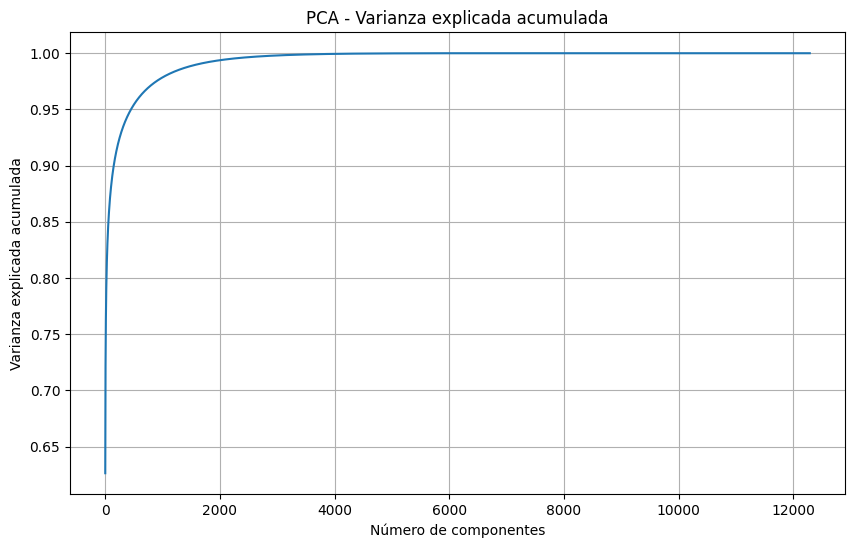

In [24]:
# ------------------------------------------------------------
# Escalamiento
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ------------------------------------------------------------
# PCA inicial para analizar varianza explicada
# ------------------------------------------------------------

pca_inicial = PCA()

X_pca = pca_inicial.fit_transform(X_scaled)


# ------------------------------------------------------------
# Varianza explicada acumulada
# ------------------------------------------------------------

varianza_acumulada = np.cumsum(
    pca_inicial.explained_variance_ratio_
)


# ------------------------------------------------------------
# Gráfico de varianza explicada
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")

plt.grid(True)

plt.show()

In [25]:
def calcular_componentes_por_varianza(pca, umbrales=(0.80, 0.85, 0.90, 0.95)):
    """
    Calcula cuántos componentes principales se necesitan
    para alcanzar distintos umbrales de varianza explicada acumulada.
    """
    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

    resultados = []

    for umbral in umbrales:
        m = np.argmax(varianza_acumulada >= umbral) + 1

        resultados.append({
            "umbral_varianza": umbral,
            "porcentaje_varianza": f"{umbral * 100:.0f}%",
            "componentes_necesarios": m,
            "varianza_acumulada": varianza_acumulada[m - 1]
        })

    return pd.DataFrame(resultados)

In [26]:
tabla_componentes = calcular_componentes_por_varianza(
    pca_inicial,
    umbrales=(0.80, 0.85, 0.90, 0.95)
)

display(tabla_componentes)

,umbral_varianza,porcentaje_varianza,componentes_necesarios,varianza_acumulada
0,0.80,80%,23,0.801680
1,0.85,85%,56,0.850159
2,0.90,90%,149,0.900021
3,0.95,95%,451,0.950072


In [27]:
def aplicar_pca_con_m_componentes(X_scaled, m):
    """
    Aplica PCA con m componentes y devuelve el espacio reducido.
    """
    pca = PCA(n_components=m)
    X_reducido = pca.fit_transform(X_scaled)

    return X_reducido, pca

In [28]:
m = 149

X_reducido, pca_final = aplicar_pca_con_m_componentes(X_scaled, m)

print(X_reducido.shape)

(27000, 149)


In [29]:
def evaluar_kmeans(X, rango_k=range(2, 13), random_state=42, muestra_silueta=5000):
    """
    Evalúa K-Means para distintos valores de k usando inercia y silueta.
    """
    resultados = []

    for k in rango_k:
        modelo = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X)

        silueta = silhouette_score(
            X,
            etiquetas,
            sample_size=muestra_silueta,
            random_state=random_state
        )

        resultados.append({
            "k": k,
            "inercia_sse": modelo.inertia_,
            "silueta": silueta
        })

    return pd.DataFrame(resultados)

In [30]:
tabla_kmeans = evaluar_kmeans(
    X_reducido,
    rango_k=range(2, 13),
    random_state=42,
    muestra_silueta=5000
)

display(tabla_kmeans)

NameError: name 'KMeans' is not defined